<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%204.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## datetime 오브젝트



*  ** datetime 라이브러리**는 날짜와 시간을 처리하는 등의 다양한 기능을 제공하는 파이썬 라이브러리이다. 이 라이브러리에는 날짜를 처리하는 **date 오브젝트**, 시간을 처리하는 **time 오브젝트**, 날짜와 시간 모두를 처리하는 **datetime 오브젝트**가 포함되어 있다. (* 이외에도 많은 오브젝트가 포함되어 있다.)


In [1]:
from datetime import datetime  ## datetime 오브젝트를 사용하기 위해 datetime 라이브러리를 불러온다

In [3]:
now1 = datetime.now()
print(now1)

now2 = datetime.today()
print(now2)

## now, today 메서드를 사용하면 다음과 같이 현재 시간을 출력할 수 있다
## now 메서드는 밀리초 단위까지 구한다

2026-03-21 12:45:25.843793
2026-03-21 12:45:25.843987


In [4]:
t1 = datetime.now()
t2 = datetime(1970, 1, 1)
t3 = datetime(1970, 12, 12, 13, 24, 34)
## datetime 오브젝트를 생성할 때 시간을 직접 입력해 인자로 전달할 수 있다

print(t1)
print(t2)
print(t3)
## 각 변수를 출력해 확인해보면 입력한 시간을 바탕으로 datetime 오브젝트가 생성된 것을 알 수 있다

2026-03-21 12:47:05.954046
1970-01-01 00:00:00
1970-12-12 13:24:34


In [5]:
diff1 = t1 - t2
print(diff1)
print(type(diff1))

diff2 = t2 - t1
print(diff2)
print(type(diff2))

## datetime 오브젝트를 사용하는 이유 중 하나는 시간 계산을 할 수 있다는 점이다

20533 days, 12:47:05.954046
<class 'datetime.timedelta'>
-20534 days, 11:12:54.045954
<class 'datetime.timedelta'>


### datetime 오브젝트로 변환하기 - to_datetime 메서드



*   경우에 따라서는 시계열 데이터를 문자열로 저장해야 할 때도 있다. 하지만 문자열은 시간 계산을 할 수 없기 때문에 datetime 오브젝트로 변환해주어야 한다. 이때 **to_datetime 메서드**를 사용하면 문자열을 datetime 오브젝트로 변환할 수 있다.



In [9]:
import pandas as pd
import os

ebola = pd.read_csv('/content/country_timeseries.csv')  ## ebola 데이터 집합부터 불러온다

In [10]:
print(ebola.info())  ## ebola 데이터프레임을 보면 문자열로 저장된 Date 열이 있는 것을 알 수 있다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

In [12]:
ebola['date_dt'] = pd.to_datetime(ebola['Date'])  ## to_datetime 메서드를 사용하면 Date열의 자료형을 datetime 오브젝트로 변환할 수 있다
print(ebola.info())
## to_datetime 메서드를 사용해 i) Date 열의 자료형을 datetime 오브젝트로 변환하고 ii) ebola 데이터프레임에 새로운 열로 추가한다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

In [15]:
test_df1 = pd.DataFrame({'order_day':['01/01/15', '02/01/15', '03/01/15']})

## 시간 형식 지정자 (%d, %m, %y)와 기호(/, -)를 적절히 조합해 format 인자에 전달하면 그 형식에 맞게 정리된 datetime 오브젝트를 얻을 수 있다
test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format = '%d/%m/%y')
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format = '%m/%d/%y')
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format = '%y/%m/%d')

print(test_df1)

test_df2 = pd.DataFrame({'order_day' : ['01-01-15', '02-01-15', '03-01-15']})
test_df2['date_dt'] = pd.to_datetime(test_df2['order_day'], format = '%d-%m-%y')

print(test_df2)

  order_day   date_dt1   date_dt2   date_dt3
0  01/01/15 2015-01-01 2015-01-01 2001-01-15
1  02/01/15 2015-01-02 2015-02-01 2002-01-15
2  03/01/15 2015-01-03 2015-03-01 2003-01-15
  order_day    date_dt
0  01-01-15 2015-01-01
1  02-01-15 2015-01-02
2  03-01-15 2015-01-03


### 시간 형식 지정자



*   %a 요일 출력 (e.g.) Sun, Mon, ..., Sat
*   %A 요일 출력(긴 이름) (e.g.) Sunday, Monday, ..., Saturday
*   %w 요일 출력(숫자, 0부터 일요일) (e.g.) 0, 1, ..., 6
*   %d 날짜 출력(2자리로 표시) (e.g.) 01, 02, ..., 31
*   %b 월 출력 (e.g.) Jan, Feb, ..., Dec
*   %B 월 출력(긴 이름) (e.g.) January, February, ..., December
*   %m 월 출력(숫자) (e.g.) 01, 02, ..., 12
*   %y 년 출력(2자리로 표시) (e.g.) 00, 01, ..., 99
*   %Y 년 출력(4자리로 표시) (e.g.) 0001, 0002, ...., 2013, 2014, ...., 9999
*   %H 시간 출력(24시간) (e.g.) 00, 01, ..., 23
*   %I 시간 출력(12시간) (e.g.) 01, 02, ..., 12
*   %p AM 또는 PM 출력 (e.g.) AM, PM
*   %M 분 출력(2자리로 표시) (e.g.) 00, 01, ..., 59
*   %S 초 출력(2자리로 표시) (e.g.) 00, 01, ..., 59
*   %f 마이크로초 출력 (e.g.) 000000, 000001, ..., 999999
*   %z UTC 차이 출력(+HHMM이나 -HHMM 형태) (e.g.) (None), +0000, -0400, +1030
*   %Z 기준 지역 이름 출력 (e.g.) (None), UTC, EST, CST
*   %j 올해의 지난 일 수 출력(1일, 2일, ...) (e.g.) 001, 002, ..., 366
*   %U 올해의 지난 주 수 출력(1주, 2주, ...) (e.g.) 00, 01, ..., 53
*   %c 날짜와 시간 출력 (e.g.) Tue Aug 16 21:30:00 1988
*   %x 날짜 출력 (e.g.) 08/16/88 (None);08/16/1988
*   %X 시간 출력 (e.g.) 21:30:00
*   %G 년 출력(ISO 8601 형식) (e.g.) 0001, 0002, ..., 2013, 2014, ..., 9999
*   %u 요일 출력(ISO 8601 형식) (e.g.) 1, 2, ..., 7
*   %V 올해의 지난 주 수 출력(ISO 8601 형식) (e.g.) 01, 02, ..., 53



*   now 메서드로 얻은 현재 시간의 시계열 데이터는 아주 정밀한 단위까지 시간을 표현한다. 하지만 원하는 시계열 데이터의 시간 요소가 연도 월, 일뿐이라면 now 메서드로 얻은 시계열 데이터를 **strftime 메서드**와 **시간 형식 지정자**를 이용해 잘라내야 한다.





In [17]:
now = datetime.now()
print(now)

nowDate = now.strftime('%Y-%m-%d')
print(nowDate)

nowTime = now.strftime('%H:%M:%S')
print(nowTime)

nowDatetime = now.strftime('%Y-%m-%d %H:%M:%S')
print(nowDatetime)

2026-03-21 13:35:31.806533
2026-03-21
13:35:31
2026-03-21 13:35:31


### datetime 오브젝트로 변환하기 - read_csv 메서드



*   앞에서는 to_datetime 메서드를 통해 문자열로 저장되어 있는 Date 열을 datetime 오브젝트로 변환했다. 그러나 datetime 오브젝트로 변환하려는 열을 지정해 데이터 집합을 불러오는 것이 더 간단하다.



In [19]:
ebola1 = pd.read_csv('/content/country_timeseries.csv', parse_dates=['Date'])
print(ebola1.info())

## read_csv 메서드의 parse_dates 인자에 datetime 오브젝트로 변환하고자 하는 열의 이름을 전달해 데이터 집합을 불러온다
## 결과를 보면 Date 열이 문자열이 아닌 datetime 오브젝트임을 확인할 수 있다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[ns]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

### datetime 오브젝트에서 날짜 정보 추출하기


*   datetime 오브젝트에는 년, 월, 일과 같은 날짜 정보를 따로 저장하고 있는 속성이 이미 준비되어 있다.



In [20]:
date_series = pd.Series(['2018-05-16', '2018-05-17', '2018-05-18'])  ## 문자열로 저장된 날짜를 시리즈에 담아 datetime 오브젝트로 변환한다
d1 = pd.to_datetime(date_series)
print(d1)

0   2018-05-16
1   2018-05-17
2   2018-05-18
dtype: datetime64[ns]


In [22]:
print(d1[0].year)
print(d1[0].month)
print(d1[0].day)

## datetime 오브젝트의 year, month, day 속성을 이용하면 년, 월, 일 정보를 바로 추출할 수 있다

2018
5
16


### dt 접근자 사용하기



*   문자열을 처리하려면 str 접근자를 사용한 다음 문자열 속성이나 메서드를 사용해야 했다. datetime 오브젝트도 마찬가지로 **dt 접근자**를 사용하면 datetime 속성이나 메서드를 사용해 시계열 데이터를 처리할 수 있다.



In [23]:
ebola = pd.read_csv('/content/country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date'])

## 먼저 ebola 데이터 집합을 불러온 다음 Date 열을 datetime 오브젝트로 변환하여 새로운 열로 추가한다

In [26]:
print(ebola[['Date', 'date_dt']].head())
print(ebola['date_dt'][3].year)
print(ebola['date_dt'][3].month)
print(ebola['date_dt'][3].day)

## dt 접근자를 사용하지 않고 인덱스가 3인 데이터의 년, 월, 일 데이터를 추출한다

         Date    date_dt
0    1/5/2015 2015-01-05
1    1/4/2015 2015-01-04
2    1/3/2015 2015-01-03
3    1/2/2015 2015-01-02
4  12/31/2014 2014-12-31
2015
1
2


In [28]:
ebola['year'] = ebola['date_dt'].dt.year

print(ebola[['Date', 'date_dt', 'year']].head())

## dt 접근자로 date_dt 열에 한 번에 접근한 다음 year 속성을 이용해 연도값을 추출한다
## 추출한 연도값은 ebola 데이터프레임의 새로운 열(year)로 추가된다

         Date    date_dt  year
0    1/5/2015 2015-01-05  2015
1    1/4/2015 2015-01-04  2015
2    1/3/2015 2015-01-03  2015
3    1/2/2015 2015-01-02  2015
4  12/31/2014 2014-12-31  2014


In [29]:
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day)

print(ebola[['Date', 'date_dt', 'year', 'month', 'day']].head())

## 월, 일 데이터를 한 번에 추출해 새로운 열(month, day)로 추가한다

         Date    date_dt  year  month  day
0    1/5/2015 2015-01-05  2015      1    5
1    1/4/2015 2015-01-04  2015      1    4
2    1/3/2015 2015-01-03  2015      1    3
3    1/2/2015 2015-01-02  2015      1    2
4  12/31/2014 2014-12-31  2014     12   31


In [31]:
print(ebola.info())  ## date_dt열은 datetime 오브젝트이고 나머지는 정수형이라는 것을 알 수 있다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

## 사례별 시계열 데이터 계산하기

### 에볼라 최초 발병일 계산하기

In [32]:
print(ebola.iloc[-5:, :5])

## ebola 데이터프레임의 마지막 행과 열을 5개씩만 살펴본다
## ebola 데이터프레임은 데이터가 시간 역순으로 정렬되어 있으므로 시간 순으로 데이터를 살펴보려면 데이터프레임의 마지막부터 살펴봐야 한다

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN


In [35]:
print(ebola['date_dt'].min())
print(type(ebola['date_dt'].min()))

## 121행에서 볼 수 있듯이 에볼라가 발생하기 시작한 날은 2014년 3월 22일
## min 메서드를 통해 에볼라의 최초 발병일을 찾는다
## timestamp는 Datetime 오브젝트와 호환되는 자료형이다

2014-03-22 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [36]:
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()

print(ebola[['Date', 'Day', 'outbreak_d']].head())

## Date 열에서 에볼라의 최초 발병일을 빼면 에볼라의 진행 정도를 알 수 있다

         Date  Day outbreak_d
0    1/5/2015  289   289 days
1    1/4/2015  288   288 days
2    1/3/2015  287   287 days
3    1/2/2015  286   286 days
4  12/31/2014  284   284 days


### 파산한 은행의 개수 계산하기

In [39]:
banks = pd.read_csv('/content/banklist.csv')
print(banks.head())

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  
0   1802            United Fidelity Bank, fsb    26-May-17    26-Jul-17  
1  30003  First-Citizens Bank & Trust Company     5-May-17    26-Jul-17  
2  58302                         Whitney Bank    28-Apr-17    26-Jul-17  
3  35495                    Cache Valley Bank     3-Mar-17    18-May-17  
4  19328                  State Bank of Texas    27-Jan-17    18-May-17  


In [41]:
banks_no_dates = pd.read_csv('/content/banklist.csv')
print(banks_no_dates.info())

banks = pd.read_csv('/content/banklist.csv', parse_dates=[5, 6])
print(banks.info())

## Closing Date, Updated Date 열의 데이터 자료형은 문자열이므로, read_csv 메서드의 parse_dates 속성을 이용해 문자열로 저장된 두 열을 datatime 오브젝트로 변환해 불러왔다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              553 non-null    object
 1   City                   553 non-null    object
 2   ST                     553 non-null    object
 3   CERT                   553 non-null    int64 
 4   Acquiring Institution  553 non-null    object
 5   Closing Date           553 non-null    object
 6   Updated Date           553 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              553 non-null    object        
 1   City                   553 non-null    object        
 2   ST                     553 non-null 

/tmp/ipykernel_5376/2969669443.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv', parse_dates=[5, 6])
/tmp/ipykernel_5376/2969669443.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('/content/banklist.csv', parse_dates=[5, 6])


In [42]:
banks['closing quarter'], banks['closing_year'] = (banks['Closing Date'].dt.quarter, banks['Closing Date'].dt.year)
print(banks.head())

## dt 접근자와 quarter 속성을 이용하면 은행이 파산한 분기를 알 수 있다
## dt 접근자와 year, quarter 속성을 이용하여 은행이 파산한 연도, 분기를 새로운 열로 추가한다

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  \
0   1802            United Fidelity Bank, fsb   2017-05-26   2017-07-26   
1  30003  First-Citizens Bank & Trust Company   2017-05-05   2017-07-26   
2  58302                         Whitney Bank   2017-04-28   2017-07-26   
3  35495                    Cache Valley Bank   2017-03-03   2017-05-18   
4  19328                  State Bank of Texas   2017-01-27   2017-05-18   

   closing quarter  closing_year  
0                2          2017 

In [43]:
closing_year = banks.groupby(['closing_year']).size()
print(closing_year)

# 연도별로 파산한 은행의 개수를 groupby 메서드를 사용해 구한다

closing_year
2000      2
2001      4
2002     11
2003      3
2004      4
2007      3
2008     25
2009    140
2010    157
2011     92
2012     51
2013     24
2014     18
2015      8
2016      5
2017      6
dtype: int64


In [45]:
closing_year_q = banks.groupby(['closing_year', 'closing quarter']).size()
print(closing_year_q)

## banks 데이터프레임을 연도별로 그룹화한 다음 다시 분기별로 그룹화해 출력하면 각 연도별, 분기별로 파산한 은행의 개수를 알 수 있다

closing_year  closing quarter
2000          4                   2
2001          1                   1
              2                   1
              3                   2
2002          1                   6
              2                   2
              3                   1
              4                   2
2003          1                   1
              2                   1
              4                   1
2004          1                   3
              2                   1
2007          1                   1
              3                   1
              4                   1
2008          1                   2
              2                   2
              3                   9
              4                  12
2009          1                  21
              2                  24
              3                  50
              4                  45
2010          1                  41
              2                  45
              3                  4

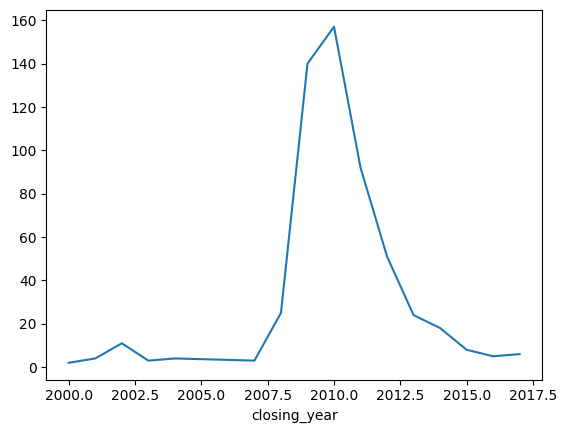

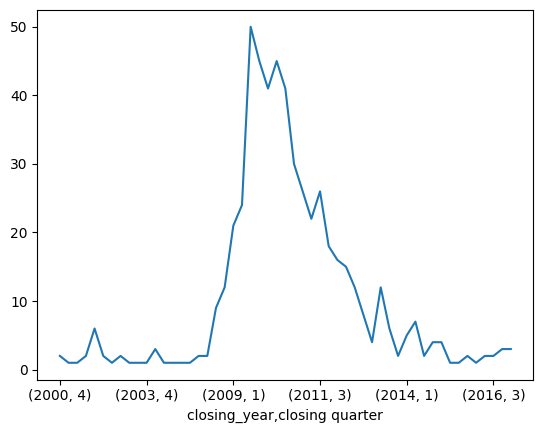

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax = closing_year.plot()
plt.show()

fig, ax = plt.subplots()
ax = closing_year_q.plot()
plt.show()

### 테슬라 주식 데이터로 시간 계산하기




In [1]:
pip install pandas-datareader

In [8]:
import pandas as pd
import pandas_datareader as pdr
pd.core.common.is_list_like = pd.api.types.is_list_like

# tesla = pdr.get_data_quandl('TSLA', api_key = '받은 key')  ## tesla에는 데이터프레임이 저장된다
# tesla.to_csv('/content/tesla_stock_quandl.csv')  ## tesla에 저장된 데이터프레임을 파일로 저장한다

tesla = pd.read_csv('/content/tesla_stock_quandl.csv')

## get_data_quanal 메서드에 TSLA라는 문자열을 전달하여 테슬라의 주식 데이터를 내려받고 to_csv 메서드를 사용해 data 폴더 안에 저장한다

In [9]:
print(tesla.head())

## tesla 데이터프레임의 Date 열은 문자열로 저장되어 있어 datetime 오브젝트로 자료형 변환을 해야 시간 계산이 가능하다

         Date    Open    High     Low   Close      Volume  ExDividend  \
0  2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
1  2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2  2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
3  2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
4  2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

   SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
0         1.0   304.00   304.27  277.18    279.18  13696168.0  
1         1.0   307.34   307.59  291.36    304.18   8324639.0  
2         1.0   311.25   311.61  300.45    301.54   6600538.0  
3         1.0   313.89   318.82  308.18    309.10   4914307.0  
4         1.0   310.25   322.44  310.19    316.53   5927881.0  


In [11]:
tesla = pd.read_csv('/content/tesla_stock_quandl.csv', parse_dates=[0])
print(tesla.info())

## date열을 Datetime 형으로 변환하려면 read_csv 메서드로 데이터 집합을 불러올 때 parse_dates 인자에 Date 열을 전달하면 된다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1949 non-null   datetime64[ns]
 1   Open        1949 non-null   float64       
 2   High        1949 non-null   float64       
 3   Low         1949 non-null   float64       
 4   Close       1949 non-null   float64       
 5   Volume      1949 non-null   float64       
 6   ExDividend  1949 non-null   float64       
 7   SplitRatio  1949 non-null   float64       
 8   AdjOpen     1949 non-null   float64       
 9   AdjHigh     1949 non-null   float64       
 10  AdjLow      1949 non-null   float64       
 11  AdjClose    1949 non-null   float64       
 12  AdjVolume   1949 non-null   float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 198.1 KB
None


In [12]:
print(tesla.loc[(tesla.Date.dt.year == 2010) & (tesla.Date.dt.month == 6)])

## Date 열의 자료형이 datetime 오브젝트로 변환되었으므로 이제 dt 접근자를 사용할 수 있다
## 불린 추출로 2010년 6월의 데이터만 추출한다

           Date   Open     High    Low  Close      Volume  ExDividend  \
1947 2010-06-30  25.79  30.4192  23.30  23.83  17187100.0         0.0   
1948 2010-06-29  19.00  25.0000  17.54  23.89  18766300.0         0.0   

      SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  
1947         1.0    25.79  30.4192   23.30     23.83  17187100.0  
1948         1.0    19.00  25.0000   17.54     23.89  18766300.0  


### datetime 오브젝트를 인덱스로 설정해 데이터 추출하기

In [13]:
tesla.index = tesla['Date']
print(tesla.index)

## Date 열을 tesla 데이터프레임의 인덱스로 지정한다

DatetimeIndex(['2018-03-27', '2018-03-26', '2018-03-23', '2018-03-22',
               '2018-03-21', '2018-03-20', '2018-03-19', '2018-03-16',
               '2018-03-15', '2018-03-14',
               ...
               '2010-07-13', '2010-07-12', '2010-07-09', '2010-07-08',
               '2010-07-07', '2010-07-06', '2010-07-02', '2010-07-01',
               '2010-06-30', '2010-06-29'],
              dtype='datetime64[ns]', name='Date', length=1949, freq=None)


In [19]:
print(tesla.loc['2015'].iloc[:5, :5])

## datetime 오브젝트를 인덱스로 지정하면 원하는 시간의 데이터를 바로 추출할 수 있다

                 Date    Open     High       Low   Close
Date                                                    
2015-12-31 2015-12-31  238.51  243.450  238.3700  240.01
2015-12-30 2015-12-30  236.60  243.634  235.6707  238.09
2015-12-29 2015-12-29  230.06  237.720  229.5470  237.19
2015-12-28 2015-12-28  231.49  231.980  225.5400  228.95
2015-12-24 2015-12-24  230.56  231.880  228.2800  230.57


In [20]:
print(tesla.loc['2010-06'].iloc[:, :5])

                 Date   Open     High    Low  Close
Date                                               
2010-06-30 2010-06-30  25.79  30.4192  23.30  23.83
2010-06-29 2010-06-29  19.00  25.0000  17.54  23.89


### 시간 간격과 인덱스 - TimedeltaIndex



*   예를 들어 주식 데이터에서 최초 5일간 수집된 데이터만 살펴보고 싶다면, 시간 간격을 인덱스로 지정해 데이터를 추출하면 된다.



### 시간 간격을 인덱스로 지정해 데이터 추출하기

In [21]:
tesla['ref_date'] = tesla['Date'] - tesla['Date'].min()
print(tesla.head())

## Date 열에서 Date 열의 최솟값을 빼면 데이터를 수집한 이후에 시간이 얼마나 흘렀는지 알 수 있다

                 Date    Open    High     Low   Close      Volume  ExDividend  \
Date                                                                            
2018-03-27 2018-03-27  304.00  304.27  277.18  279.18  13696168.0         0.0   
2018-03-26 2018-03-26  307.34  307.59  291.36  304.18   8324639.0         0.0   
2018-03-23 2018-03-23  311.25  311.61  300.45  301.54   6600538.0         0.0   
2018-03-22 2018-03-22  313.89  318.82  308.18  309.10   4914307.0         0.0   
2018-03-21 2018-03-21  310.25  322.44  310.19  316.53   5927881.0         0.0   

            SplitRatio  AdjOpen  AdjHigh  AdjLow  AdjClose   AdjVolume  \
Date                                                                     
2018-03-27         1.0   304.00   304.27  277.18    279.18  13696168.0   
2018-03-26         1.0   307.34   307.59  291.36    304.18   8324639.0   
2018-03-23         1.0   311.25   311.61  300.45    301.54   6600538.0   
2018-03-22         1.0   313.89   318.82  308.18    309.10   4

In [22]:
tesla.index = tesla['ref_date']
print(tesla.iloc[:5, :5])

## 시간 간격(ref_date)을 이용해 데이터를 추출한다

                Date    Open    High     Low   Close
ref_date                                            
2828 days 2018-03-27  304.00  304.27  277.18  279.18
2827 days 2018-03-26  307.34  307.59  291.36  304.18
2824 days 2018-03-23  311.25  311.61  300.45  301.54
2823 days 2018-03-22  313.89  318.82  308.18  309.10
2822 days 2018-03-21  310.25  322.44  310.19  316.53


In [23]:
print(tesla['5 days':].iloc[:5, :5])

## 데이터를 수집한 이후 최초 5일의 데이터

               Date   Open     High    Low  Close
ref_date                                         
3 days   2010-07-02  23.00  23.1000  18.71  19.20
2 days   2010-07-01  25.00  25.9200  20.27  21.96
1 days   2010-06-30  25.79  30.4192  23.30  23.83
0 days   2010-06-29  19.00  25.0000  17.54  23.89


### 시간 범위와 인덱스



*   만약 특정 일에 누락된 데이터도 포함시켜 데이터를 살펴보려면, 임의로 시간 범위를 생성해 인덱스로 지정해야 한다.

### 시간 범위 생성해 인덱스로 지정하기



In [24]:
ebola = pd.read_csv('/content/country_timeseries.csv', parse_dates=[0])
print(ebola.iloc[:5, :5])

## 2015년 01월 01일의 데이터가 누락된 것을 알 수 있다

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


In [25]:
print(ebola.iloc[-5:, :5])

## 뒤쪽의 2014년 03월 23일의 데이터가 누락되었음을 알 수 있다

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [26]:
head_range = pd.date_range(start='2014-12-31', end='2015-01-05')
print(head_range)

## date_range 메서드를 사용해 2014년 12월 31일부터 2015년 01월 05일 사이의 시간 인덱스를 생성한다

DatetimeIndex(['2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', freq='D')


In [27]:
ebola_5 = ebola.head()
## 원본 데이터를 손상시키는 것을 방지하기 위해 ebola 데이터프레임의 앞쪽 5개의 데이터를 추출해 새로운 데이터프레임을 만든다
## 이 때 반드시 Date 열을 인덱스로 먼저 지정한 후 시간 범위를 인덱스로 지정해야 한다
ebola_5.index = ebola_5['Date']
ebola_5.reindex(head_range)
print(ebola_5.iloc[:5, :5])

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                      
2015-01-05 2015-01-05  289        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286           NaN         8157.0                NaN
2014-12-31 2014-12-31  284        2730.0         8115.0             9633.0


### 시간 범위의 주기 설정하기 - freq 속성값으로 사용할 수 있는 시간 주기



*   시간 범위를 인덱스로 지정하면 DatetimeIndex 자료형이 만들어지는데, 이 안에는 freq 속성이 포함되어 있다. freq 속성값을 지정하면 시간 간격을 조절해 DatetimeIndex를 만들 수 있다.
*   B 평일만 포함
*   C 사용자가 정의한 평일만 포함
*   D 달력 일자 단위
*   W 주간 단위
*   M 월 마지막 날만 포함
*   SM 15일과 월 마지막 날만 포함
*   BM M 주기의 값이 휴일이면 제외하고 평일만 포함
*   CBM BM에 사용자 정의 평일을 적용
*   MS 월 시작일만 포함
*   SMS 월 시작일과 15일만 포함
*   BMS MS 주기의 값이 휴일이면 제외하고 평일만 포함
*   CBMS BMS에 사용자 정의 평일을 적용
*   Q 3, 6, 9, 12월 분기 마지막 날만 포함
*   BQ 3, 6, 9, 12월 분기 마지막 날이 휴일이면 제외하고 평일만 포함
*   QS 3, 6, 9, 12월 분기 시작일만 포함
*   BQS 3, 6, 9, 12월 분기 시작일이 휴일이면 제외하고 평일만 포함
*   A 년의 마지막 날만 포함
*   BA 년의 마지막 날이 휴일이면 제외하고 평일만 포함
*   AS 년의 시작일만 포함
*   BAS 년의 시작일이 휴일이면 제외하고 평일만 포함
*   BH 평일을 시간 단위로 포함(09:00 ~ 16:00)
*   H 시간 단위로 포함(00:00 ~ 00:00)
*   T 분 단위 포함
*   S 초 단위 포함
*   L 밀리초 단위 포함
*   U 마이크로초 단위 포함
*   N 나노초 단위 포함



In [29]:
print(pd.date_range('2017-01-01', '2017-01-07', freq='B'))

## date_range 메서드의 freq 인잣값을 B로 설정하여 평일만 포함시킨 DatetimeIndex를 만든다

DatetimeIndex(['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-05',
               '2017-01-06'],
              dtype='datetime64[ns]', freq='B')


### 시간 범위 수정하고 데이터 밀어내기 - shift 메서드

### 에볼라의 확산 속도 비교하기



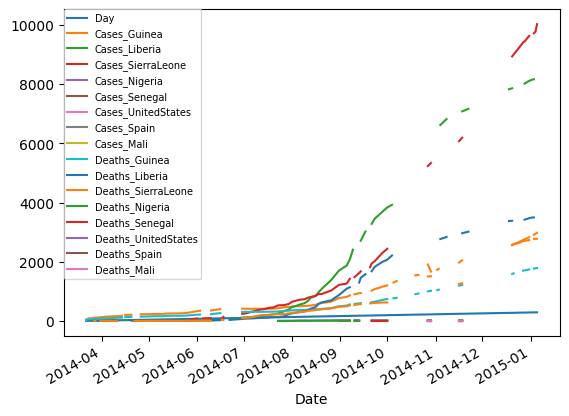

In [30]:
import matplotlib.pyplot as plt

ebola.index = ebola['Date']

fig, ax = plt.subplots()
## ebola 데이터프레임의 Date 열을 인덱스로 지정한 다음 x축을 Date 열로, y축을 사망자 수로 지정해 그래프를 그린다
ax = ebola.iloc[0:, 1:].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)
plt.show()

In [32]:
ebola_sub = ebola[['Day', 'Cases_Guinea', 'Cases_Liberia']]
print(ebola_sub.tail(10))

## 그런데 위 그래프는 각 나라의 에볼라 발병일이 달라 그래프가 그려지기 시작한 지점이 다르다
## 각 나라의 발병일을 가장 처음 에볼라가 발병한 Guinea와 동일한 위치로 옮겨야 나라별 에볼라의 확산 속도를 제대로 비교할 수 있다

            Day  Cases_Guinea  Cases_Liberia
Date                                        
2014-04-04   13         143.0           18.0
2014-04-01   10         127.0            8.0
2014-03-31    9         122.0            8.0
2014-03-29    7         112.0            7.0
2014-03-28    6         112.0            3.0
2014-03-27    5         103.0            8.0
2014-03-26    4          86.0            NaN
2014-03-25    3          86.0            NaN
2014-03-24    2          86.0            NaN
2014-03-22    0          49.0            NaN


In [60]:
ebola = pd.read_csv('/content/country_timeseries.csv', parse_dates=['Date'])
## Date 열의 자료형을 datetime 오브젝트로 변환해 ebola 데이터프레임을 다시 생성한다

print(ebola.head().iloc[:, :5])
print(ebola.tail().iloc[:, :5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0
          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [61]:
ebola.index = ebola['Date']
new_idx = pd.date_range(ebola.index.min(), ebola.index.max())

## Date 열을 인덱스로 지정한 다음 ebola 데이터프레임의 Date 열의 최댓값과 최솟값으로 시간 범위를 생성해 new_idx에 저장한다
## 날짜가 아예 없었던 데이터의 인덱스를 생성한다

In [62]:
print(new_idx)
new_idx = reversed(new_idx)

## 그러나 new_idx를 살펴보면 ebola 데이터 집합에 있는 시간 순서와 반대로 생성되어 있다
## reversed 메서드를 통해 인덱스를 반대로 뒤집는다

DatetimeIndex(['2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31',
               ...
               '2014-12-27', '2014-12-28', '2014-12-29', '2014-12-30',
               '2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', length=290, freq='D')


In [63]:
ebola = ebola.reindex(new_idx)

print(ebola.head().iloc[:, :5])
print(ebola.tail().iloc[:, :5])

                 Date    Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                        
2015-01-05 2015-01-05  289.0        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288.0        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287.0        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286.0           NaN         8157.0                NaN
2015-01-01        NaT    NaN           NaN            NaN                NaN
                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                      
2014-03-26 2014-03-26  4.0          86.0            NaN                NaN
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN
2014-03-24 2014-03-24  2.0          86.0            NaN                NaN
2014-03-23        NaT  NaN           NaN            NaN                NaN
2014-03-22 

In [65]:
last_valid = ebola.apply(pd.Series.last_valid_index)
print(last_valid)

first_valid = ebola.apply(pd.Series.first_valid_index)
print(first_valid)

## last_valid_index, first_valid_index 메서드를 사용해 각 나라의 에볼라 발병일을 구한다
## 각각의 메서드는 유효한 값이 있는 첫 번째와 마지막 인덱스를 반환한다

Date                  2014-03-22
Day                   2014-03-22
Cases_Guinea          2014-03-22
Cases_Liberia         2014-03-27
Cases_SierraLeone     2014-03-27
Cases_Nigeria         2014-07-23
Cases_Senegal         2014-08-31
Cases_UnitedStates    2014-10-01
Cases_Spain           2014-10-08
Cases_Mali            2014-10-22
Deaths_Guinea         2014-03-22
Deaths_Liberia        2014-03-27
Deaths_SierraLeone    2014-03-27
Deaths_Nigeria        2014-07-23
Deaths_Senegal        2014-09-07
Deaths_UnitedStates   2014-10-01
Deaths_Spain          2014-10-08
Deaths_Mali           2014-10-22
dtype: datetime64[ns]
Date                  2015-01-05
Day                   2015-01-05
Cases_Guinea          2015-01-05
Cases_Liberia         2015-01-03
Cases_SierraLeone     2015-01-05
Cases_Nigeria         2014-12-07
Cases_Senegal         2014-12-07
Cases_UnitedStates    2014-12-07
Cases_Spain           2014-12-07
Cases_Mali            2014-12-07
Deaths_Guinea         2015-01-05
Deaths_Liberia       

In [66]:
earliest_date = ebola.index.min()
print(earliest_date)

shift_values = last_valid - earliest_date
print(shift_values)

## 각 나라의 에볼라 발병일을 동일한 출발선으로 옮기려면 에볼라가 가장 처음 발병한 날에서 각 나라의 에볼라 발병일을 뺀 만큼 옮긴다

2014-03-22 00:00:00
Date                    0 days
Day                     0 days
Cases_Guinea            0 days
Cases_Liberia           5 days
Cases_SierraLeone       5 days
Cases_Nigeria         123 days
Cases_Senegal         162 days
Cases_UnitedStates    193 days
Cases_Spain           200 days
Cases_Mali            214 days
Deaths_Guinea           0 days
Deaths_Liberia          5 days
Deaths_SierraLeone      5 days
Deaths_Nigeria        123 days
Deaths_Senegal        169 days
Deaths_UnitedStates   193 days
Deaths_Spain          200 days
Deaths_Mali           214 days
dtype: timedelta64[ns]


In [67]:
ebola_dict = {}
for idx, col in enumerate(ebola) :
  d = shift_values[idx].days
  shifted = ebola[col].shift(d)
  ebola_dict[col] = shifted

## shift 메서드를 사용해 모든 열의 값을 shift_values 값만큼, 각 나라의 에볼라 발병일을 옮긴다

/tmp/ipykernel_15996/2547632249.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  d = shift_values[idx].days


In [68]:
ebola_shift = pd.DataFrame(ebola_dict)

## ebola_dict에는 시간을 다시 설정한 데이터가 딕셔너리 형태로 저장되어 있다
## DataFrame 메서드를 이용해 ebola_dict의 값을 데이터프레임으로 변환한다

In [69]:
print(ebola_shift.tail())

## 에볼라의 최초 발병일을 기준으로 모든 열의 데이터를 옮긴다

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone  \
Date                                                                         
2014-03-26 2014-03-26  4.0          86.0            8.0                2.0   
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN   
2014-03-24 2014-03-24  2.0          86.0            7.0                NaN   
2014-03-23        NaT  NaN           NaN            3.0                2.0   
2014-03-22 2014-03-22  0.0          49.0            8.0                6.0   

            Cases_Nigeria  Cases_Senegal  Cases_UnitedStates  Cases_Spain  \
Date                                                                        
2014-03-26            1.0            NaN                 1.0          1.0   
2014-03-25            NaN            NaN                 NaN          NaN   
2014-03-24            NaN            NaN                 NaN          NaN   
2014-03-23            NaN            NaN                 NaN        

In [70]:
ebola_shift.index = ebola_shift['Day']
ebola_shift = ebola_shift.drop(['Date', 'Day'], axis=1)

print(ebola_shift.tail())

## 마지막으로 인덱스를 Day 열로 지정하고 그래프에 필요 없는 Date, Day 열을 삭제한다

     Cases_Guinea  Cases_Liberia  Cases_SierraLeone  Cases_Nigeria  \
Day                                                                  
4.0          86.0            8.0                2.0            1.0   
3.0          86.0            NaN                NaN            NaN   
2.0          86.0            7.0                NaN            NaN   
NaN           NaN            3.0                2.0            NaN   
0.0          49.0            8.0                6.0            0.0   

     Cases_Senegal  Cases_UnitedStates  Cases_Spain  Cases_Mali  \
Day                                                               
4.0            NaN                 1.0          1.0         NaN   
3.0            NaN                 NaN          NaN         NaN   
2.0            NaN                 NaN          NaN         NaN   
NaN            NaN                 NaN          NaN         NaN   
0.0            1.0                 1.0          1.0         1.0   

     Deaths_Guinea  Deaths_Liberia  Dea

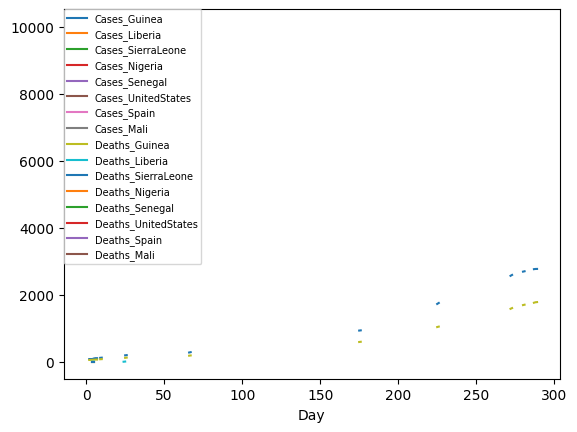

In [71]:
## 지금까지 만든 데이터프레임으로 다시 그린 그래프

fig, ax = plt.subplots()
ax = ebola_shift.iloc[:, :].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)
plt.show()